# Stage 07 — CAFEIN mobility-context POC

## Purpose

Stage 06 established the **observed behavioural response at H3 level**.

Stage 07 asks a different question:

> **Among places where observed activity is important and persistent, do mobility-accessibility conditions suggest fewer practical alternatives?**

This is a **proof of concept**, not a validated transport-poverty measure.

The logic is:

**Observed behaviour (Locomizer) → select important/persistent H3 cells → calculate CAFEIN accessibility context → identify potentially constrained places**

## What this notebook does

1. loads the Stage 06 H3 behavioural profile;
2. identifies a small set of high-priority H3 cells;
3. uses CAFEIN to calculate walking and cycling travel times from those cells to opportunities;
4. summarizes the nearest-opportunity travel burden;
5. combines accessibility with behavioural persistence;
6. maps a simple exploratory "constraint context" classification.

The CAFEIN documentation supports street travel-time matrices between arbitrary point GeoDataFrames and multiple transport modes.


## 1. Imports and paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import cafein.sampledata.helsinki as helsinki
from cafein import StreetNetwork, TravelTimeMatrix

PROJECT_ROOT = Path("/scratch/project_2010417")

STAGE06_DIR_CANDIDATES = [
    Path("../outputs/v3/06_h3_behavioural_response"),
    PROJECT_ROOT / "paper3" / "outputs" / "v3" / "06_h3_behavioural_response",
]

MAP_H3_RESOLUTION = 9

PROFILE_NAME = (
    f"stage06_h3_res{MAP_H3_RESOLUTION}_ff_profile.csv"
)

H3_GPKG_NAME = (
    f"stage06_h3_res{MAP_H3_RESOLUTION}_behavioural_response.gpkg"
)

PERSISTENCE_GPKG_NAME = (
    f"stage06_h3_res{MAP_H3_RESOLUTION}_temporal_persistence.gpkg"
)

STREET_NETWORK_CANDIDATES = [
    Path("helsinki-region-streets.cafein"),
    PROJECT_ROOT / "paper3" / "helsinki-region-streets.cafein",
    PROJECT_ROOT / "paper3" / "cafein" / "helsinki-region-streets.cafein",
    PROJECT_ROOT / "paper3" / "networks" / "helsinki-region-streets.cafein",
]

OUTPUT_DIR = Path(
    "../outputs/v3/07_cafein_accessibility_context"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Keep this small for a proof of concept
N_ORIGINS = 30

# Accessibility threshold used only for descriptive POC classification.
# It is NOT a policy or health threshold.
WALK_CONSTRAINT_MIN = 20
BIKE_CONSTRAINT_MIN = 10

print("Output:", OUTPUT_DIR.resolve())


Output: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/07_cafein_accessibility_context


## 2. Find Stage 06 outputs

In [2]:
def first_existing(directory_candidates, filename):
    checked = []
    for directory in directory_candidates:
        path = directory / filename
        checked.append(path)
        if path.exists():
            print("Using:", path.resolve())
            return path

    raise FileNotFoundError(
        "Could not find file. Checked:\n"
        + "\n".join(str(p) for p in checked)
    )

profile_path = first_existing(
    STAGE06_DIR_CANDIDATES,
    PROFILE_NAME,
)

h3_gpkg_path = first_existing(
    STAGE06_DIR_CANDIDATES,
    H3_GPKG_NAME,
)

persistence_gpkg_path = first_existing(
    STAGE06_DIR_CANDIDATES,
    PERSISTENCE_GPKG_NAME,
)


Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/06_h3_behavioural_response/stage06_h3_res9_ff_profile.csv
Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/06_h3_behavioural_response/stage06_h3_res9_behavioural_response.gpkg
Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/06_h3_behavioural_response/stage06_h3_res9_temporal_persistence.gpkg


## 3. Load the behavioural profile and H3 geometry

In [3]:
profile = pd.read_csv(
    profile_path
)

h3_geo = gpd.read_file(
    h3_gpkg_path,
    layer=f"h3_res{MAP_H3_RESOLUTION}_behavioural_response",
)

persistence_geo = gpd.read_file(
    persistence_gpkg_path,
    layer=f"h3_res{MAP_H3_RESOLUTION}_temporal_persistence",
)

print("Profile rows:", len(profile))
print("H3 geometry rows:", len(h3_geo))
print("Persistence rows:", len(persistence_geo))

display(profile.head())


Profile rows: 2545
H3 geometry rows: 2545
Persistence rows: 2545


,display_h3,footfall_A,footfall_B,pct_change_footfall,activity_share_A,activity_share_B,relative_activity_shift,n_same_hour_comparisons,persistence_rate,median_same_hour_pct_change,activity_importance_rank,persistence_rank,poc_priority_score
0,89089960acfffff,1,3,200.0,0.000085,0.000261,0.000176,18,0.777778,0.0,0.116110,0.985462,0.114422
1,89089961357ffff,2,1,-50.0,0.000170,0.000087,-0.000083,135,0.688889,0.0,0.320432,0.918861,0.294433
2,89089961373ffff,4,4,0.0,0.000340,0.000348,0.000007,229,0.537118,0.0,0.598232,0.099411,0.059471
3,89089961453ffff,2,2,0.0,0.000170,0.000174,0.000004,106,0.556604,0.0,0.320432,0.200000,0.064086
4,8908996145bffff,2,2,0.0,0.000170,0.000174,0.000004,189,0.645503,0.0,0.320432,0.810609,0.259745


## 4. Build the integrated H3 behavioural table

The key behavioural indicators are:

- `activity_share_A`: baseline importance;
- `persistence_rate`: how often activity stayed stable/increased in same-hour comparisons;
- `relative_activity_shift`: whether the cell gained/lost regional activity share;
- `poc_priority_score`: combined behavioural importance and persistence.


In [4]:
h3_context = (
    h3_geo[
        [
            "display_h3",
            "geometry",
        ]
    ]
    .merge(
        profile,
        on="display_h3",
        how="left",
    )
)

h3_context = gpd.GeoDataFrame(
    h3_context,
    geometry="geometry",
    crs=h3_geo.crs,
)

display(
    h3_context.sort_values(
        "poc_priority_score",
        ascending=False,
    ).head(20)
)


,display_h3,geometry,footfall_A,footfall_B,pct_change_footfall,activity_share_A,activity_share_B,relative_activity_shift,n_same_hour_comparisons,persistence_rate,median_same_hour_pct_change,activity_importance_rank,persistence_rank,poc_priority_score
733,8908996b073ffff,"POLYGON ((24.66397 60.14675, 24.66665 60.14607...",10,13,30.000000,0.000851,0.001130,0.000279,215,0.646512,0.000000,0.904126,0.813360,0.735379
437,8908996988bffff,"POLYGON ((24.80464 60.17638, 24.80732 60.17569...",10,2,-80.000000,0.000851,0.000174,-0.000677,191,0.638743,0.000000,0.904126,0.780550,0.705715
1651,891126d1977ffff,"POLYGON ((25.09286 60.21247, 25.09555 60.21178...",8,5,-37.500000,0.000681,0.000435,-0.000246,237,0.649789,0.000000,0.848723,0.826719,0.701655
990,8908996d493ffff,"POLYGON ((24.80229 60.26881, 24.80498 60.26813...",15,13,-13.333333,0.001276,0.001130,-0.000146,204,0.622549,0.000000,0.968173,0.699018,0.676770
1230,891126c242fffff,"POLYGON ((25.1131 60.23688, 25.11579 60.23619,...",8,5,-37.500000,0.000681,0.000435,-0.000246,233,0.639485,0.000000,0.848723,0.785462,0.666639
164,89089968553ffff,"POLYGON ((24.70071 60.19798, 24.70339 60.1973,...",5,5,0.000000,0.000425,0.000435,0.000009,184,0.733696,0.000000,0.689587,0.965815,0.666014
618,8908996a48bffff,"POLYGON ((24.58431 60.19811, 24.58699 60.19743...",5,4,-20.000000,0.000425,0.000348,-0.000078,96,0.729167,0.000000,0.689587,0.963851,0.664659
1953,891126d2a17ffff,"POLYGON ((24.96674 60.24323, 24.96942 60.24254...",8,5,-37.500000,0.000681,0.000435,-0.000246,166,0.638554,0.000000,0.848723,0.779764,0.661804
1893,891126d26a7ffff,"POLYGON ((24.86501 60.20851, 24.8677 60.20782,...",5,3,-40.000000,0.000425,0.000261,-0.000165,176,0.721591,0.000000,0.689587,0.957564,0.660324
1572,891126d0d13ffff,"POLYGON ((25.01626 60.26177, 25.01895 60.26108...",13,17,30.769231,0.001106,0.001478,0.000372,240,0.620833,5.409357,0.951670,0.689194,0.655886


## 5. Select a small set of H3 origins for the POC

Rather than route thousands of H3 cells, select the top cells by behavioural priority.

This keeps the CAFEIN routing step fast and makes the integration easy to inspect.


In [5]:
selected = (
    h3_context
    .dropna(
        subset=[
            "poc_priority_score",
            "persistence_rate",
            "activity_share_A",
        ]
    )
    .sort_values(
        "poc_priority_score",
        ascending=False,
    )
    .head(N_ORIGINS)
    .copy()
)

print("Selected origins:", len(selected))

display(
    selected[
        [
            "display_h3",
            "footfall_A",
            "pct_change_footfall",
            "persistence_rate",
            "activity_share_A",
            "poc_priority_score",
        ]
    ]
)


Selected origins: 30


,display_h3,footfall_A,pct_change_footfall,persistence_rate,activity_share_A,poc_priority_score
733,8908996b073ffff,10,30.000000,0.646512,0.000851,0.735379
437,8908996988bffff,10,-80.000000,0.638743,0.000851,0.705715
1651,891126d1977ffff,8,-37.500000,0.649789,0.000681,0.701655
990,8908996d493ffff,15,-13.333333,0.622549,0.001276,0.676770
1230,891126c242fffff,8,-37.500000,0.639485,0.000681,0.666639
164,89089968553ffff,5,0.000000,0.733696,0.000425,0.666014
618,8908996a48bffff,5,-20.000000,0.729167,0.000425,0.664659
1953,891126d2a17ffff,8,-37.500000,0.638554,0.000681,0.661804
1893,891126d26a7ffff,5,-40.000000,0.721591,0.000425,0.660324
1572,891126d0d13ffff,13,30.769231,0.620833,0.001106,0.655886


## 6. Create routing origin points

In [6]:
origins = selected.to_crs("EPSG:4326").copy()

origins["geometry"] = (
    origins.geometry.representative_point()
)

origins = origins.rename(
    columns={"display_h3": "id"}
)

origins = origins[
    [
        "id",
        "persistence_rate",
        "activity_share_A",
        "relative_activity_shift",
        "poc_priority_score",
        "geometry",
    ]
].copy()

display(origins.head())


,id,persistence_rate,activity_share_A,relative_activity_shift,poc_priority_score,geometry
733,8908996b073ffff,0.646512,0.000851,0.000279,0.735379,POINT (24.66641 60.14777)
437,8908996988bffff,0.638743,0.000851,-0.000677,0.705715,POINT (24.80709 60.17739)
1651,891126d1977ffff,0.649789,0.000681,-0.000246,0.701655,POINT (25.09533 60.21348)
990,8908996d493ffff,0.622549,0.001276,-0.000146,0.676770,POINT (24.80475 60.26983)
1230,891126c242fffff,0.639485,0.000681,-0.000246,0.666639,POINT (25.11557 60.23789)


## 7. Define opportunity destinations

For this POC, shopping centres are used as a generic set of urban opportunities.

They are **not** intended to represent all essential destinations or a validated accessibility measure. They simply demonstrate how observed H3 behaviour can be connected to a CAFEIN accessibility layer.


In [7]:
opportunities = gpd.read_file(
    helsinki.pois.shopping_centre
).to_crs("EPSG:4326")

opportunities = opportunities.loc[
    opportunities.geometry.notna()
].copy()

opportunities["id"] = [
    f"opp_{i}"
    for i in range(len(opportunities))
]

keep_cols = [
    "id",
    "geometry",
]

if "name" in opportunities.columns:
    keep_cols.insert(1, "name")

destinations = opportunities[
    keep_cols
].copy()

print("Opportunity destinations:", len(destinations))
display(destinations.head())


Opportunity destinations: 88


,id,name,geometry
0,opp_0,Kauppatalo,POINT (24.7534 60.37931)
1,opp_1,Porttipuiston liikekeskus,POINT (25.08949 60.27997)
2,opp_2,Myllypuron ostoskeskus,POINT (25.07356 60.22421)
3,opp_3,Jumbo,POINT (24.96514 60.29154)
4,opp_4,Kauppakeskus Itis,POINT (25.08266 60.21174)


## 8. Load or build the CAFEIN street network

In [8]:
street_path = None

for candidate in STREET_NETWORK_CANDIDATES:
    if candidate.exists():
        street_path = candidate
        break

if street_path is not None:
    print("Loading:", street_path.resolve())
    streets = StreetNetwork.load(
        street_path,
        mmap=True,
    )

else:
    print(
        "No saved street network found. "
        "Building one from the CAFEIN Helsinki sample OSM extract."
    )

    streets = StreetNetwork.from_osm(
        helsinki.osm_pbf,
        modes=(
            "walk",
            "bicycle",
            "e_scooter",
            "wheelchair",
            "car",
        ),
        dem=helsinki.dem,
        dem_interval=25,
        country="FI",
    )

print(streets)


Loading: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/notebooks/helsinki-region-streets.cafein
StreetNetwork(1474309 vertices, 1644890 edges)


## 9. Calculate walking and cycling travel-time matrices

CAFEIN's matrix output contains `from_id`, `to_id`, and `travel_time`.

We calculate two simple accessibility contexts:

- walking time to opportunities;
- cycling time to opportunities.


In [9]:
walk_matrix = TravelTimeMatrix(
    streets,
    origins,
    destinations,
    transport_mode="walk",
)

bike_matrix = TravelTimeMatrix(
    streets,
    origins,
    destinations,
    transport_mode="bicycle",
)

print("Walking matrix rows:", len(walk_matrix))
print("Cycling matrix rows:", len(bike_matrix))

display(walk_matrix.head())


Walking matrix rows: 388
Cycling matrix rows: 2106


,from_id,to_id,travel_time
0,8908996b073ffff,opp_6,86
1,8908996b073ffff,opp_16,114
2,8908996b073ffff,opp_26,14
3,8908996b073ffff,opp_34,81
4,8908996b073ffff,opp_35,59


## 10. Summarize accessibility by H3 origin

For each selected H3 origin, calculate:

- nearest opportunity travel time;
- median travel time to all reachable opportunities;
- number of reachable opportunities represented in the matrix.

This is an accessibility **context**, not a transport-poverty index.


In [10]:
def summarize_matrix(matrix, prefix):
    summary = (
        matrix
        .groupby(
            "from_id",
            as_index=False,
        )
        .agg(
            nearest_min=(
                "travel_time",
                "min",
            ),
            median_min=(
                "travel_time",
                "median",
            ),
            reachable_n=(
                "to_id",
                "nunique",
            ),
        )
    )

    return summary.rename(
        columns={
            "from_id": "id",
            "nearest_min": f"{prefix}_nearest_min",
            "median_min": f"{prefix}_median_min",
            "reachable_n": f"{prefix}_reachable_n",
        }
    )

walk_summary = summarize_matrix(
    walk_matrix,
    "walk",
)

bike_summary = summarize_matrix(
    bike_matrix,
    "bike",
)

accessibility = (
    origins
    .merge(
        walk_summary,
        on="id",
        how="left",
    )
    .merge(
        bike_summary,
        on="id",
        how="left",
    )
)

display(
    accessibility.sort_values(
        "walk_nearest_min",
        ascending=False,
    )
)


,id,persistence_rate,activity_share_A,relative_activity_shift,poc_priority_score,geometry,walk_nearest_min,walk_median_min,walk_reachable_n,bike_nearest_min,bike_median_min,bike_reachable_n
6,8908996a48bffff,0.729167,0.000425,-0.000078,0.664659,POINT (24.58675 60.19913),105,105.0,1,27,72.0,55
12,891126d7577ffff,0.644351,0.000595,0.000187,0.651049,POINT (25.00908 60.31621),59,81.0,6,17,64.0,69
25,8908996a10fffff,0.642424,0.000510,-0.000076,0.604514,POINT (24.6534 60.22148),56,87.0,5,12,63.0,65
24,890899689a3ffff,0.626087,0.000681,0.000450,0.609113,POINT (24.80393 60.25692),51,76.5,20,14,57.0,75
15,891126d0e97ffff,0.640000,0.000595,-0.000248,0.635820,POINT (25.01244 60.23151),49,86.0,15,13,61.0,75
4,891126c242fffff,0.639485,0.000681,-0.000246,0.666639,POINT (25.11557 60.23789),46,77.0,12,12,75.5,68
19,891126d0977ffff,0.621622,0.000851,0.000192,0.628447,POINT (25.07032 60.26599),43,70.0,8,11,66.0,72
7,891126d2a17ffff,0.638554,0.000681,-0.000246,0.661804,POINT (24.9692 60.24424),41,88.0,10,11,52.0,75
29,891126d2387ffff,0.664062,0.000425,0.000183,0.597191,POINT (24.90946 60.22505),40,110.0,20,11,50.0,75
20,891126d2b3bffff,0.680723,0.000425,-0.000251,0.623745,POINT (24.99518 60.26388),38,72.0,7,11,55.0,75


## 11. Create a simple mobility-constraint context

For the POC only:

- **lower constraint**: nearest opportunity within 20 min walking OR 10 min cycling;
- **higher constraint**: neither condition is met.

This is deliberately named a **mobility-constraint context**, not transport poverty.

A genuine transport-poverty measure would additionally require socioeconomic, affordability, car-availability, service-quality, and/or accessibility evidence.


In [11]:
accessibility["lower_cost_access_option"] = (
    (accessibility["walk_nearest_min"] <= WALK_CONSTRAINT_MIN)
    |
    (accessibility["bike_nearest_min"] <= BIKE_CONSTRAINT_MIN)
)

accessibility["mobility_context"] = np.where(
    accessibility["lower_cost_access_option"],
    "lower accessibility constraint",
    "higher accessibility constraint",
)

accessibility["persistent_activity"] = (
    accessibility["persistence_rate"] >= 0.5
)

accessibility["integrated_context"] = np.select(
    [
        (
            accessibility["persistent_activity"]
            &
            accessibility["lower_cost_access_option"]
        ),
        (
            accessibility["persistent_activity"]
            &
            ~accessibility["lower_cost_access_option"]
        ),
        (
            ~accessibility["persistent_activity"]
            &
            accessibility["lower_cost_access_option"]
        ),
        (
            ~accessibility["persistent_activity"]
            &
            ~accessibility["lower_cost_access_option"]
        ),
    ],
    [
        "persistent activity + lower accessibility constraint",
        "persistent activity + higher accessibility constraint",
        "lower persistence + lower accessibility constraint",
        "lower persistence + higher accessibility constraint",
    ],
    default="unclassified",
)

display(
    accessibility[
        [
            "id",
            "persistence_rate",
            "activity_share_A",
            "walk_nearest_min",
            "bike_nearest_min",
            "mobility_context",
            "integrated_context",
        ]
    ]
)


,id,persistence_rate,activity_share_A,walk_nearest_min,bike_nearest_min,mobility_context,integrated_context
0,8908996b073ffff,0.646512,0.000851,14,5,lower accessibility constraint,persistent activity + lower accessibility cons...
1,8908996988bffff,0.638743,0.000851,6,2,lower accessibility constraint,persistent activity + lower accessibility cons...
2,891126d1977ffff,0.649789,0.000681,16,5,lower accessibility constraint,persistent activity + lower accessibility cons...
3,8908996d493ffff,0.622549,0.001276,23,7,lower accessibility constraint,persistent activity + lower accessibility cons...
4,891126c242fffff,0.639485,0.000681,46,12,higher accessibility constraint,persistent activity + higher accessibility con...
5,89089968553ffff,0.733696,0.000425,36,10,lower accessibility constraint,persistent activity + lower accessibility cons...
6,8908996a48bffff,0.729167,0.000425,105,27,higher accessibility constraint,persistent activity + higher accessibility con...
7,891126d2a17ffff,0.638554,0.000681,41,11,higher accessibility constraint,persistent activity + higher accessibility con...
8,891126d26a7ffff,0.721591,0.000425,16,5,lower accessibility constraint,persistent activity + lower accessibility cons...
9,891126d0d13ffff,0.620833,0.001106,25,7,lower accessibility constraint,persistent activity + lower accessibility cons...


## 12. Map the integrated behavioural + accessibility context

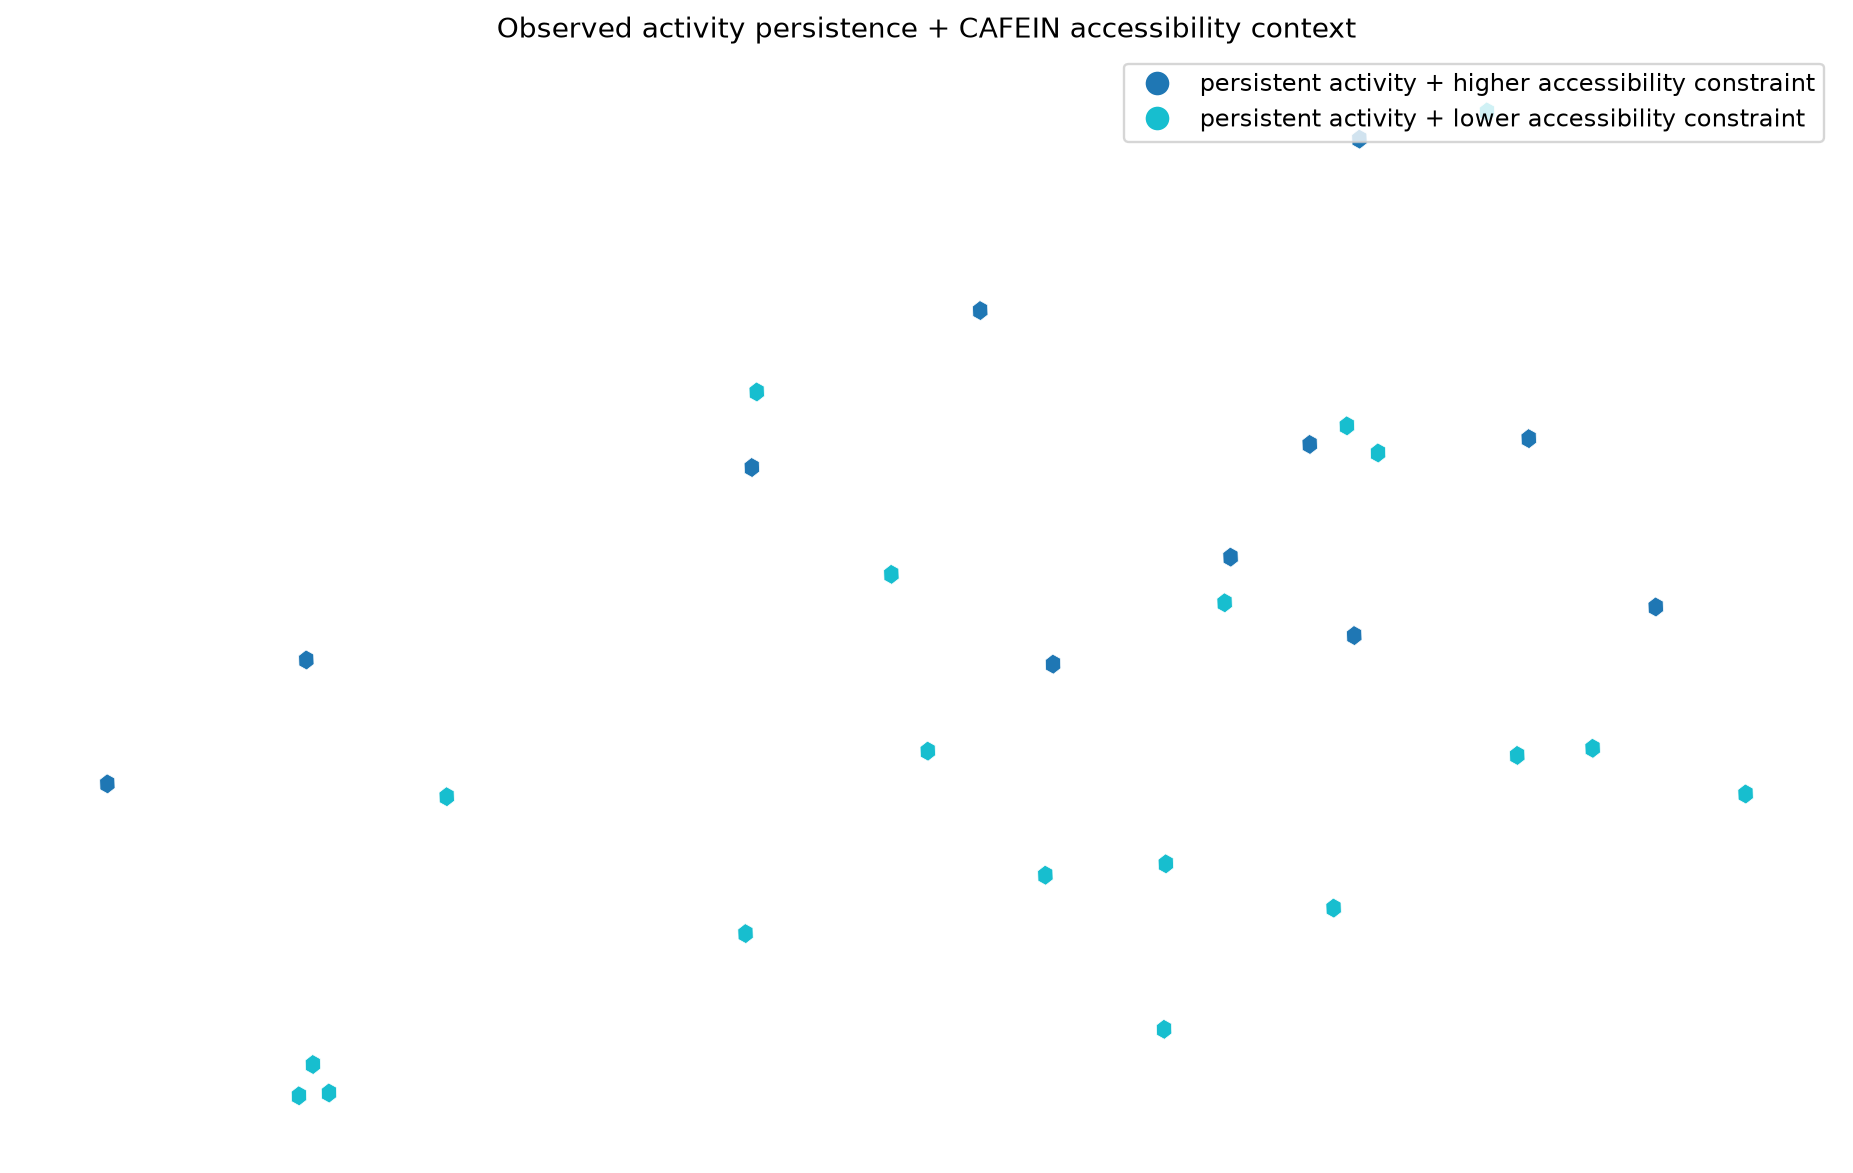

In [12]:
mapped = selected[
    [
        "display_h3",
        "geometry",
    ]
].rename(
    columns={"display_h3": "id"}
).merge(
    accessibility.drop(
        columns="geometry"
    ),
    on="id",
    how="left",
)

mapped = gpd.GeoDataFrame(
    mapped,
    geometry="geometry",
    crs=selected.crs,
).to_crs("EPSG:3067")

fig, ax = plt.subplots(
    figsize=(11, 9),
    dpi=170,
)

mapped.plot(
    ax=ax,
    column="integrated_context",
    categorical=True,
    legend=True,
    linewidth=0.3,
    edgecolor="white",
)

ax.set_title(
    "Observed activity persistence + CAFEIN accessibility context"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()


## 13. Rank potentially constrained persistent-activity locations

These are the most interesting cells for the next stage of the POC:

> locations with important/persistent observed activity and comparatively weaker walking/cycling access to the selected opportunities.


In [13]:
priority_context = (
    accessibility.loc[
        accessibility["persistent_activity"]
    ]
    .copy()
)

priority_context["access_burden_score"] = (
    priority_context["walk_nearest_min"].rank(
        pct=True,
        method="average",
    )
    +
    priority_context["bike_nearest_min"].rank(
        pct=True,
        method="average",
    )
) / 2

priority_context["integrated_priority_score"] = (
    priority_context["poc_priority_score"]
    * priority_context["access_burden_score"]
)

display(
    priority_context.sort_values(
        "integrated_priority_score",
        ascending=False,
    )[
        [
            "id",
            "persistence_rate",
            "activity_share_A",
            "relative_activity_shift",
            "walk_nearest_min",
            "bike_nearest_min",
            "access_burden_score",
            "integrated_priority_score",
        ]
    ].head(20)
)


,id,persistence_rate,activity_share_A,relative_activity_shift,walk_nearest_min,bike_nearest_min,access_burden_score,integrated_priority_score
6,8908996a48bffff,0.729167,0.000425,-0.000078,105,27,1.000000,0.664659
12,891126d7577ffff,0.644351,0.000595,0.000187,59,17,0.966667,0.629347
15,891126d0e97ffff,0.640000,0.000595,-0.000248,49,13,0.883333,0.561641
4,891126c242fffff,0.639485,0.000681,-0.000246,46,12,0.841667,0.561088
24,890899689a3ffff,0.626087,0.000681,0.000450,51,14,0.916667,0.558354
25,8908996a10fffff,0.642424,0.000510,-0.000076,56,12,0.891667,0.539025
7,891126d2a17ffff,0.638554,0.000681,-0.000246,41,11,0.750000,0.496353
19,891126d0977ffff,0.621622,0.000851,0.000192,43,11,0.766667,0.481810
20,891126d2b3bffff,0.680723,0.000425,-0.000251,38,11,0.716667,0.447017
18,8908996d147ffff,0.688119,0.000425,-0.000251,37,11,0.700000,0.443070


## 14. Interpretation for the POC

This notebook does **not** say that accessibility caused observed behavioural persistence.

It demonstrates that the workflow can combine:

1. observed behavioural information from Locomizer;
2. spatial H3 screening;
3. CAFEIN network-based travel-time accessibility;
4. a transparent exploratory classification of potentially constrained areas.

That is enough for the methodological proof of concept.

A later substantive study could replace the generic opportunity set with:
- cleaner-air spaces;
- hospitals/health services;
- transit hubs;
- workplaces;
- cooling centres;
- grocery stores;
- or other destinations relevant to the environmental event.

It could also replace the simple accessibility proxy with a validated transport-poverty index.


## 15. Optional next CAFEIN extension: environmental route context

For a small number of the highest-priority cells, the next technical extension can calculate actual route environmental attributes.

CAFEIN can attach environmental layers such as PM₂.₅, road noise, and Green View to street-based routes. The sample PM₂.₅ layer is a **single FMI-ENFUSER model hour**, so it should only be used to demonstrate the route-exposure machinery, not interpreted as the environmental condition corresponding to the Locomizer observation dates.


## 16. Save Stage 07 outputs

In [14]:
accessibility_csv = (
    OUTPUT_DIR
    / "stage07_cafein_accessibility_context.csv"
)

mapped_gpkg = (
    OUTPUT_DIR
    / "stage07_cafein_accessibility_context.gpkg"
)

priority_csv = (
    OUTPUT_DIR
    / "stage07_persistent_activity_accessibility_priority.csv"
)

walk_matrix_csv = (
    OUTPUT_DIR
    / "stage07_walk_matrix.csv"
)

bike_matrix_csv = (
    OUTPUT_DIR
    / "stage07_bike_matrix.csv"
)

accessibility.drop(
    columns="geometry"
).to_csv(
    accessibility_csv,
    index=False,
)

mapped.to_file(
    mapped_gpkg,
    layer="h3_accessibility_context",
    driver="GPKG",
)

priority_context.to_csv(
    priority_csv,
    index=False,
)

walk_matrix.to_csv(
    walk_matrix_csv,
    index=False,
)

bike_matrix.to_csv(
    bike_matrix_csv,
    index=False,
)

print("Saved:")
for p in [
    accessibility_csv,
    mapped_gpkg,
    priority_csv,
    walk_matrix_csv,
    bike_matrix_csv,
]:
    print(" -", p)


Saved:
 - ../outputs/v3/07_cafein_accessibility_context/stage07_cafein_accessibility_context.csv
 - ../outputs/v3/07_cafein_accessibility_context/stage07_cafein_accessibility_context.gpkg
 - ../outputs/v3/07_cafein_accessibility_context/stage07_persistent_activity_accessibility_priority.csv
 - ../outputs/v3/07_cafein_accessibility_context/stage07_walk_matrix.csv
 - ../outputs/v3/07_cafein_accessibility_context/stage07_bike_matrix.csv
